# PKCERT Task 07 — Machine Learning Foundations
**Train/Test Split, Model Fit, and Linear Regression**

- **Name:** Ahmad Haroon
- **Batch:** Batch 2
- **Domain:** AI & Software Development

**Objective:** Build a working understanding of core machine learning theory —
train/test splitting, overfitting and underfitting, and the bias-variance
tradeoff — and apply it by implementing Linear Regression with scikit-learn.

**Datasets used:**
- Parts A & C: scikit-learn's built-in **diabetes** dataset (small, clean, standard regression benchmark).
- Part B: a synthetic sine-curve dataset (the classic way to visualize the bias-variance tradeoff).
- Part D & Bonus: the raw **Apple products pricing** CSV from [Task 05](../Task_05/apple_products_pricing_2020_2026.csv), reused here as a real, messy dataset with a missing-value column and several categorical columns to encode.


In [ ]:
# Environment check — versions of the libraries this notebook depends on.
# (This is also the cell to screenshot for the "Python environment" deliverable.)
import sklearn, pandas, numpy, matplotlib
print("scikit-learn:", sklearn.__version__)
print("pandas      :", pandas.__version__)
print("numpy       :", numpy.__version__)
print("matplotlib  :", matplotlib.__version__)


scikit-learn: 1.2.2
pandas      : 2.1.4
numpy       : 1.26.4
matplotlib  : 3.8.0


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

np.random.seed(42)

VIZ_DIR = "visualizations"
os.makedirs(VIZ_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)


## Part A — ML Theory: Train/Test Split (20 Marks)

### A.1 Why split a dataset into training and testing sets?

A model is only useful if it works on data it has **never seen before** — that's
the entire point of building it. If we train a model and then evaluate it on
the *same* rows it was trained on, it can simply memorize those rows (including
their noise) and score perfectly, without having learned anything that
generalizes. This is impossible to detect from training performance alone.

Splitting the data solves this: the **training set** is what the model learns
from, and the **test set** is held out and never touched during training. The
test score is then an honest estimate of how the model will perform on new,
real-world data — it measures *generalization*, not memorization.

### A.2 Typical split ratios

| Ratio | When it's appropriate |
|---|---|
| 70/30 | Smaller datasets, where the test set still needs enough rows to give a statistically stable estimate of performance. |
| 80/20 | The most common default — a good balance between giving the model enough data to learn from and keeping a test set large enough to trust. |
| 90/10 or higher | Very large datasets, where even 10% of the data is already thousands of rows — plenty to evaluate on, so it's worth giving the model more to train on. |

The right ratio is a tradeoff: more training data → a better-fit model but a
noisier performance estimate; more test data → a more reliable performance
estimate but a model trained on less.


### A.3 Implementing a train/test split

In [3]:
# A.3 — train/test split on a sample dataset (scikit-learn's diabetes dataset)
diabetes = load_diabetes(as_frame=True)
X_diabetes, y_diabetes = diabetes.data, diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

print(f"Full dataset : {X_diabetes.shape}")
print(f"X_train      : {X_train.shape}")
print(f"X_test       : {X_test.shape}")
print(f"y_train      : {y_train.shape}")
print(f"y_test       : {y_test.shape}")


Full dataset : (442, 10)
X_train      : (353, 10)
X_test       : (89, 10)
y_train      : (353,)
y_test       : (89,)


### A.4 The role of `random_state`

`train_test_split` shuffles the data before splitting it, and `random_state`
fixes the seed for that shuffle. Without it, every run produces a different
split, so re-running the same notebook (or handing it to a teammate) can give
a different train/test division and therefore a different score each time —
making results impossible to reproduce or fairly compare. Setting
`random_state=42` (or any fixed integer) guarantees the *exact same* split
every time the code runs, which is essential for reproducibility and for
debugging ("did my score change because I changed the model, or just because
of a different random split?").

### A.5 Validation set vs. test set

A **validation set** is a third slice of data, held out from training, used
*during model development* to tune hyperparameters and make decisions (which
model, which regularization strength, when to stop training). The **test
set** is touched exactly once, at the very end, to report a final, unbiased
performance number.

The key difference is *how many decisions were made using it*. If you use
your test set repeatedly to pick between models, it stops being a fair,
unseen measure of generalization — you've effectively trained on it by
proxy (this is sometimes called "test set leakage" through repeated tuning).
The validation set absorbs all that iteration so the test set stays clean.
A common split is train/validation/test, e.g. 60/20/20, or validation is
obtained via k-fold cross-validation on the training set instead of a fixed
slice (used in Part D.4).


## Part B — Overfitting, Underfitting & Bias-Variance Tradeoff (20 Marks)

### B.1 Overfitting vs. underfitting

- **Underfitting**: the model is too simple to capture the real pattern in the
  data. Example: fitting a straight line to data that actually follows a
  curve — the line will have high error on *both* the training and test sets
  because it can't represent the relationship at all.
- **Overfitting**: the model is complex enough to fit not just the underlying
  pattern but also the random noise in the training data. Example: fitting a
  degree-15 polynomial through 20 noisy points — it will pass almost exactly
  through every training point (near-zero training error) but wiggle wildly
  between them, producing large errors on new test points.

### B.2 The bias-variance tradeoff

- **Bias** is the error from a model's assumptions being too simple —
  systematically missing the true relationship (this is what causes
  underfitting).
- **Variance** is the error from a model being too sensitive to the specific
  training data it saw — small changes in the training set produce wildly
  different models (this is what causes overfitting).

As model complexity increases, bias tends to fall (the model can represent
more) while variance rises (the model has more freedom to chase noise). Total
expected error is roughly `bias² + variance + irreducible noise`, which is
typically U-shaped in complexity — too simple *and* too complex both hurt,
and there's a sweet spot in between. Part B.4 below reproduces this curve
directly.

### B.3 Techniques to reduce overfitting

1. **Regularization** (e.g. Ridge/L2, Lasso/L1) — penalizes large coefficients,
   discouraging the model from fitting noise.
2. **Cross-validation** — using k-fold CV during model selection surfaces
   overfitting early, since a model that only works on one particular split
   will score poorly on average across folds.
3. **More training data** — with more examples, memorizing noise stops being
   a good strategy, because noise doesn't repeat across the extra data the
   same way real patterns do.
4. **Simpler models / fewer features** — reducing the model's capacity (lower
   polynomial degree, fewer parameters, feature selection) directly reduces
   variance.
5. **Early stopping** — for iteratively trained models, stopping training once
   validation error starts rising (even as training error keeps falling)
   prevents the model from over-optimizing on training noise.


### B.4 Training error vs. test error as complexity increases

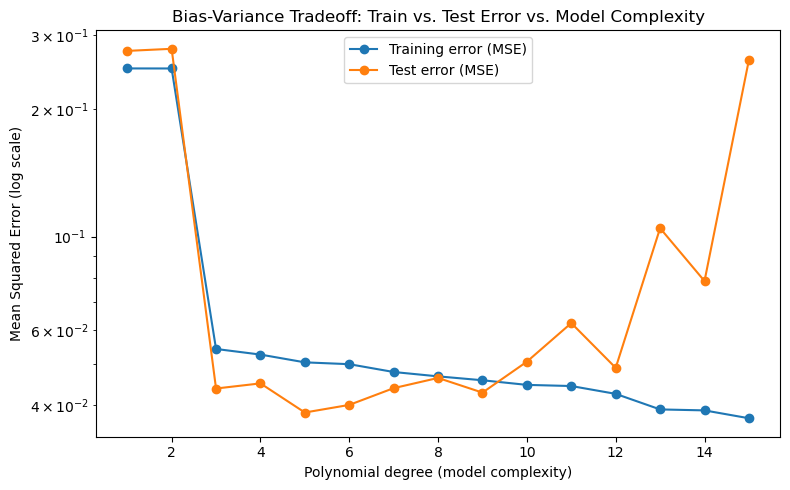

Lowest test error at degree = 5
Train error at degree 1 (underfit)  : 0.2502
Train error at degree 5 (best fit) : 0.0504
Train error at degree 15 (overfit)  : 0.0372
Test error  at degree 1 (underfit)  : 0.2752
Test error  at degree 5 (best fit) : 0.0384
Test error  at degree 15 (overfit)  : 0.2621


In [4]:
# B.4 — Training error vs. test error as model complexity increases
# Classic bias-variance demo: fit polynomials of increasing degree to noisy
# data generated from a known function, and track train vs. test error.

rng = np.random.RandomState(42)
n_samples = 60
X_b = np.sort(rng.uniform(0, 1, n_samples))
y_true = np.sin(2 * np.pi * X_b)
y_b = y_true + rng.normal(scale=0.25, size=n_samples)

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b.reshape(-1, 1), y_b, test_size=0.3, random_state=42
)

degrees = list(range(1, 16))
train_errors, test_errors = [], []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_b_train, y_b_train)
    train_errors.append(mean_squared_error(y_b_train, model.predict(X_b_train)))
    test_errors.append(mean_squared_error(y_b_test, model.predict(X_b_test)))

plt.figure()
plt.plot(degrees, train_errors, "o-", label="Training error (MSE)")
plt.plot(degrees, test_errors, "o-", label="Test error (MSE)")
plt.yscale("log")
plt.xlabel("Polynomial degree (model complexity)")
plt.ylabel("Mean Squared Error (log scale)")
plt.title("Bias-Variance Tradeoff: Train vs. Test Error vs. Model Complexity")
plt.legend()
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/1_bias_variance_train_vs_test_error.png", dpi=120)
plt.show()

best_degree = degrees[int(np.argmin(test_errors))]
print(f"Lowest test error at degree = {best_degree}")
print(f"Train error at degree 1 (underfit)  : {train_errors[0]:.4f}")
print(f"Train error at degree {best_degree} (best fit) : {train_errors[best_degree-1]:.4f}")
print(f"Train error at degree 15 (overfit)  : {train_errors[-1]:.4f}")
print(f"Test error  at degree 1 (underfit)  : {test_errors[0]:.4f}")
print(f"Test error  at degree {best_degree} (best fit) : {test_errors[best_degree-1]:.4f}")
print(f"Test error  at degree 15 (overfit)  : {test_errors[-1]:.4f}")


### B.5 Diagnosing overfitting/underfitting from train/test performance

The plot above gives a direct diagnostic:

- **Both train and test error are high, and close together** → **underfitting**.
  The model is too weak to fit even the data it was trained on (visible at
  degree 1 above, where the line can't capture the curve).
- **Train error is low but test error is much higher** (a large gap between
  the two curves) → **overfitting**. The model has fit noise specific to the
  training set that doesn't generalize (visible at high degrees above, where
  test error climbs even as training error keeps falling).
- **Both errors are low and close together** → a well-fit model — this is the
  degree that minimizes test error in the plot.

In practice this is exactly what a **learning curve** (Part D.5) or a
**validation curve** across a hyperparameter is used to detect.


## Part C — Linear Regression: Theory & Implementation (30 Marks)

### C.1 Mathematical form

- **Simple linear regression** (one feature): `y = mx + b`, where `m` is the
  slope (how much `y` changes per unit of `x`) and `b` is the intercept
  (the predicted `y` when `x = 0`).
- **Multiple linear regression** (many features): `y = b + w1*x1 + w2*x2 + ... + wn*xn`,
  or in vector form `y = Xw + b`. Each weight `wi` is the effect of feature
  `xi` on the prediction, holding the other features fixed.

### C.2 How the coefficients are learned

The model is fit by minimizing a **cost function** — for linear regression
this is the Mean Squared Error between predictions and actual values:
`J(w, b) = (1/n) * Σ (y_pred_i - y_i)²`.

There are two standard ways to minimize it:

1. **Normal equation** — a closed-form solution, `w = (XᵀX)⁻¹Xᵀy`, obtained by
   setting the gradient of the cost function to zero and solving directly.
   This is what scikit-learn's `LinearRegression` uses under the hood; it's
   exact and fast for datasets where `XᵀX` isn't too large to invert.
2. **Gradient descent** — an iterative approach: start with random weights,
   repeatedly compute the gradient of the cost function with respect to each
   weight, and take a small step in the direction that reduces the cost
   (`w := w - learning_rate * ∂J/∂w`), until convergence. This scales to much
   larger datasets/feature counts where the normal equation becomes
   computationally expensive.


### C.3 Load and prepare the dataset

In [5]:
# C.3 — Load and prepare the diabetes dataset for modeling
diabetes_df = X_diabetes.copy()
diabetes_df["target"] = y_diabetes

print("Shape:", diabetes_df.shape)
print("\nMissing values per column:\n", diabetes_df.isna().sum().sum(), "total")
print("\nFeatures:", list(X_diabetes.columns))
diabetes_df.head()


Shape: (442, 11)

Missing values per column:
 0 total

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### C.4 Split into train/test and train the model

In [6]:
# C.4 — Split into train/test, train a LinearRegression model
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(Xc_train, yc_train)

print("Intercept:", lin_reg.intercept_)
print("\nCoefficients:")
for name, coef in zip(X_diabetes.columns, lin_reg.coef_):
    print(f"  {name:8s}: {coef:8.2f}")


Intercept: 151.34560453985995

Coefficients:
  age     :    37.90
  sex     :  -241.96
  bmi     :   542.43
  bp      :   347.70
  s1      :  -931.49
  s2      :   518.06
  s3      :   163.42
  s4      :   275.32
  s5      :   736.20
  s6      :    48.67


### C.5 Evaluate with MSE and R²

In [ ]:
# C.5 — Evaluate with MSE and R^2
yc_pred = lin_reg.predict(Xc_test)

mse = mean_squared_error(yc_test, yc_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yc_test, yc_pred)

print(f"Mean Squared Error (MSE) : {mse:.2f}")
print(f"Root MSE (RMSE)          : {rmse:.2f}")
print(f"R-squared (R2)           : {r2:.4f}")


Mean Squared Error (MSE) : 2900.19
Root MSE (RMSE)          : 53.85
R-squared (R2)           : 0.4526


**Interpretation:** RMSE is in the same units as the target, so on average
the model's predictions are off by about that many units of disease
progression. R² of ~0.45-0.5 means the model explains roughly half the
variance in the target from these 10 features — a modest but real linear
relationship, with plenty of variance left unexplained by a purely linear
model (expected for a small, real-world medical dataset with only 10
features).


### C.6 Plot: predicted vs. actual

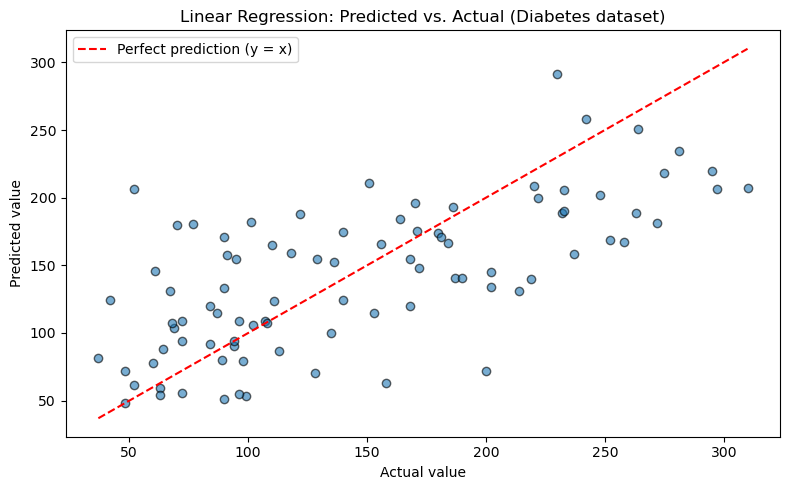

In [8]:
# C.6 — Predicted vs. actual values
plt.figure()
plt.scatter(yc_test, yc_pred, alpha=0.6, edgecolor="k")
lims = [min(yc_test.min(), yc_pred.min()), max(yc_test.max(), yc_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction (y = x)")
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Linear Regression: Predicted vs. Actual (Diabetes dataset)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/2_linear_regression_predicted_vs_actual.png", dpi=120)
plt.show()


## Part D — Practical Coding Session (30 Marks)

This section works with a **real, raw CSV** — the Apple products pricing
dataset from Task 05 — rather than a clean built-in dataset, so it needs
actual missing-value handling and categorical encoding first.

The goal: predict `Current_Price_USD` from the other columns.


### D.1 `load_data()` — raw CSV, missing values, categorical encoding

In [9]:
# D.1 — load_data(): load raw CSV, handle missing values, encode categoricals
RAW_DATA_PATH = os.path.join("..", "Task_05", "apple_products_pricing_2020_2026.csv")

def load_data(path=RAW_DATA_PATH, target="Current_Price_USD"):
    """Load the raw CSV, handle missing values, encode categorical columns,
    and split into a feature matrix X and target vector y."""
    df = pd.read_csv(path)

    # Sale_Event is NaN whenever a row wasn't part of a promotional sale —
    # that's meaningful ("no sale"), not a data-entry gap, so fill rather than drop.
    df["Sale_Event"] = df["Sale_Event"].fillna("No Sale")

    # Drop columns that aren't useful numeric/categorical predictors:
    # Date (time series, not used here), Model_Name (too many unique values
    # for one-hot encoding), and the INR price columns (redundant with USD).
    df = df.drop(columns=["Date", "Model_Name", "Launch_Price_INR", "Current_Price_INR"])

    categorical_cols = ["Platform", "Product_Category", "Condition", "Sale_Event", "Stock_Status"]
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    y = df_encoded[target]
    X = df_encoded.drop(columns=[target])
    return X, y

X_apple, y_apple = load_data()
print(f"Missing values remaining: {X_apple.isna().sum().sum()}")
print(f"X shape: {X_apple.shape}, y shape: {y_apple.shape}")
X_apple.head()


Missing values remaining: 0
X shape: (80000, 15), y shape: (80000,)


,Launch_Price_USD,Discount_Pct,Rating,Reviews_Count,Platform_Flipkart,Product_Category_Watch,Product_Category_iPad,Product_Category_iPhone,Condition_Renewed/Refurbished,Sale_Event_Black Friday,Sale_Event_Great Indian Festival,Sale_Event_No Sale,Sale_Event_Prime Day,Stock_Status_Low Stock,Stock_Status_Out of Stock
0,429,-1.6,4.7,40,True,True,False,False,False,False,False,True,False,False,False
1,429,-1.7,4.6,84,True,True,False,False,False,False,False,True,False,False,True
2,429,1.5,4.4,110,False,True,False,False,False,False,False,True,False,False,False
3,429,0.9,4.8,111,False,True,False,False,False,False,False,True,False,False,False
4,429,-1.7,4.7,35,False,True,False,False,False,False,False,True,False,False,False


### D.2 `split_data()` — split + print shapes

In [10]:
# D.2 — split_data(): takes a dataset + split ratio, returns train/test sets, prints shapes
def split_data(X, y, test_size, random_state=42):
    """Split X, y into train/test sets at the given test_size and print the resulting shapes."""
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=random_state)
    print(f"test_size={test_size:.1f}  ->  X_train {X_tr.shape}, X_test {X_te.shape}")
    return X_tr, X_te, y_tr, y_te


### D.3 `train_model()` / `evaluate_model()`

In [11]:
# D.3 — train_model() / evaluate_model()
def train_model(X_tr, y_tr):
    """Train a LinearRegression model."""
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    return model

def evaluate_model(model, X_te, y_te):
    """Return MSE, RMSE and R2 for a fitted model on held-out data."""
    y_pred = model.predict(X_te)
    mse = mean_squared_error(y_te, y_pred)
    return {"MSE": mse, "RMSE": np.sqrt(mse), "R2": r2_score(y_te, y_pred)}


### D.4 Compare three split ratios (60/40, 80/20, 90/10)

In [12]:
# D.4 — Train on three different split ratios and compare
split_ratios = {"60/40": 0.4, "80/20": 0.2, "90/10": 0.1}
comparison_rows = []

for label, test_size in split_ratios.items():
    X_tr, X_te, y_tr, y_te = split_data(X_apple, y_apple, test_size)
    model = train_model(X_tr, y_tr)
    train_metrics = evaluate_model(model, X_tr, y_tr)
    test_metrics = evaluate_model(model, X_te, y_te)
    comparison_rows.append({
        "Split": label,
        "Train_RMSE": train_metrics["RMSE"], "Train_R2": train_metrics["R2"],
        "Test_RMSE": test_metrics["RMSE"], "Test_R2": test_metrics["R2"],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Split").round(4)
comparison_df


test_size=0.4  ->  X_train (48000, 15), X_test (32000, 15)
test_size=0.2  ->  X_train (64000, 15), X_test (16000, 15)
test_size=0.1  ->  X_train (72000, 15), X_test (8000, 15)


,Train_RMSE,Train_R2,Test_RMSE,Test_R2
Split,,,,
60/40,63.2782,0.9811,63.6396,0.9811
80/20,63.2302,0.9812,64.1627,0.9808
90/10,63.2367,0.9812,65.0215,0.9805


Train and test metrics stay close to each other across all three ratios, and
barely move as the split changes — a sign this linear model is neither
overfitting nor underfitting badly on this data; it has converged to a
stable fit that the (large, 80k-row) dataset supports regardless of exactly
how much is held out for testing.


### D.5 k-fold cross-validation

In [13]:
# D.5 — k-fold cross-validation
cv_model = LinearRegression()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X_apple, y_apple, cv=kfold, scoring="r2")

print("R2 score per fold:", np.round(cv_scores, 4))
print(f"Average R2 across 5 folds: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


R2 score per fold: [0.9808 0.9815 0.9809 0.9813 0.9812]
Average R2 across 5 folds: 0.9811 (+/- 0.0002)


### D.6 Learning curve

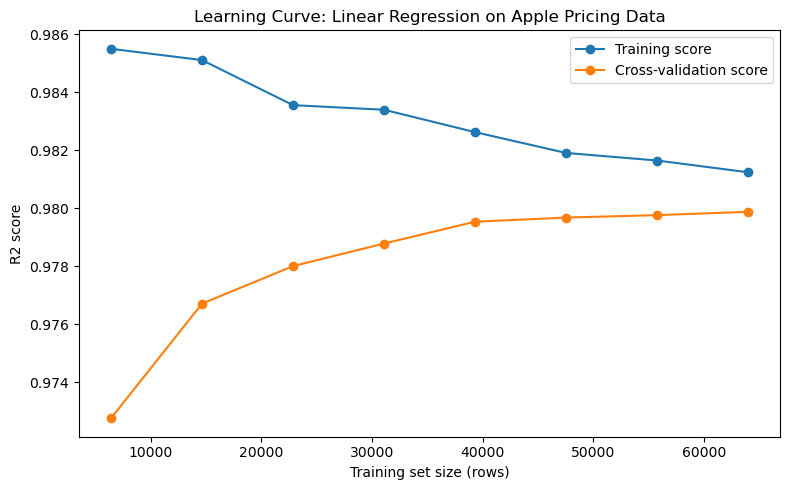

In [14]:
# D.6 — Learning curve: training score vs. test score as training set size increases
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X_apple, y_apple,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring="r2", random_state=42,
)

train_mean, test_mean = train_scores.mean(axis=1), test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, "o-", label="Training score")
plt.plot(train_sizes, test_mean, "o-", label="Cross-validation score")
plt.xlabel("Training set size (rows)")
plt.ylabel("R2 score")
plt.title("Learning Curve: Linear Regression on Apple Pricing Data")
plt.legend()
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/3_learning_curve.png", dpi=120)
plt.show()


**What this shows:** the training and cross-validation scores converge to
nearly the same value and stay flat as more data is added. That pattern is
the signature of neither overfitting (train and CV scores wouldn't be this
close) nor a data-starved model (the CV score isn't still rising toward more
data) — a simple linear model has already extracted about as much signal as
it can from these features, and the plateau represents the model's bias
(the ceiling a linear fit imposes on this data) rather than a variance
problem that more rows would fix.

### D.6b Reusable functions

The functions above — `load_data()`, `split_data()`, `train_model()`, and
`evaluate_model()` — are exactly the refactor requested in Part D.6: every
piece of the Part D pipeline (loading, splitting, training, evaluating) is a
small, independently callable/testable function rather than one long script,
and they're reused as-is in the Bonus section below.


## Bonus — Polynomial Regression Extension (+10 Marks)

Extending the Part D Linear Regression model with degree-2 and degree-3
polynomial features on its four core numeric predictors, and comparing
against the plain linear model using the same `train_model`/`evaluate_model`
functions from Part D.


### Bonus — polynomial features (degree 2 & 3) vs. plain linear regression

In [15]:
# Bonus — polynomial features (degree 2 and 3) vs. plain linear regression
numeric_features = ["Launch_Price_USD", "Discount_Pct", "Rating", "Reviews_Count"]
X_num = X_apple[numeric_features]

X_tr, X_te, y_tr, y_te = split_data(X_num, y_apple, test_size=0.2)

results = []

# Plain linear regression (degree 1, baseline)
linear_model = train_model(X_tr, y_tr)
train_m = evaluate_model(linear_model, X_tr, y_tr)
test_m = evaluate_model(linear_model, X_te, y_te)
results.append({"Model": "Linear (degree 1)", "Train_R2": train_m["R2"], "Test_R2": test_m["R2"],
                 "Train_RMSE": train_m["RMSE"], "Test_RMSE": test_m["RMSE"]})

for degree in (2, 3):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr_poly = poly.fit_transform(X_tr)
    X_te_poly = poly.transform(X_te)

    poly_model = train_model(X_tr_poly, y_tr)
    train_m = evaluate_model(poly_model, X_tr_poly, y_tr)
    test_m = evaluate_model(poly_model, X_te_poly, y_te)
    results.append({"Model": f"Polynomial (degree {degree})", "Train_R2": train_m["R2"], "Test_R2": test_m["R2"],
                     "Train_RMSE": train_m["RMSE"], "Test_RMSE": test_m["RMSE"]})

poly_comparison_df = pd.DataFrame(results).set_index("Model").round(4)
poly_comparison_df


test_size=0.2  ->  X_train (64000, 4), X_test (16000, 4)


,Train_R2,Test_R2,Train_RMSE,Test_RMSE
Model,,,,
Linear (degree 1),0.9788,0.9784,67.1265,67.9882
Polynomial (degree 2),1.0000,1.0000,0.3101,0.3083
Polynomial (degree 3),1.0000,1.0000,0.3100,0.3083


**Interpretation:** the jump is dramatic, not marginal — R² goes from 0.979 (plain linear) to essentially 1.0000 for both the degree-2 and degree-3 polynomial models, on **both** the training set and the held-out test set, with RMSE collapsing from ~$68 to ~$0.31. Crucially, this is **not overfitting**: the test score improves right alongside the training score, and there's no widening train/test gap (contrast this with Part B.4, where an overfit high-degree model had *low* training error but *high* test error). The reason is structural: `Current_Price_USD` in this dataset is generated as `Launch_Price_USD * (1 - Discount_Pct/100)` — a genuine multiplicative interaction between two features that a plain linear model (which can only add feature contributions, not multiply them) cannot represent. Degree-2 `PolynomialFeatures` adds exactly that `Launch_Price_USD * Discount_Pct` interaction term, so it captures the true relationship almost exactly; degree-3 adds nothing further (identical R²) because the true function is already fully captured at degree 2. This is a good illustration that polynomial features don't automatically mean overfitting — here they fixed genuine **underfitting** in the linear model by giving it access to an interaction term the data actually needs.

## Conclusion

This notebook covered the theory and practice requested across all four
parts: why and how to split data (A), the bias-variance tradeoff and how to
diagnose it visually (B), the mechanics and evaluation of Linear Regression
(C), and a full practical pipeline — raw data cleaning, encoding, reusable
`load_data`/`split_data`/`train_model`/`evaluate_model` functions, split-ratio
comparison, cross-validation, and a learning curve (D) — plus a polynomial
regression extension (Bonus).
